In [1]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [2]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import warnings
from scipy.signal import butter, filtfilt, detrend

In [3]:
data = loadmat("data_processed/ts_young/ts_young_TR0.72.mat")

In [4]:
fc_mean = data['FC_mean']
fc_all = data['FC_all']
ts_all = data['timeseries_all']

In [5]:
def BandPassFilter(
    boldSignal, flp=0.008, fhi=0.08, removeStrongArtefacts=True, TR=0.72, k=5
):
    # Convenience method to apply a filter (always the same one) to all areas in a BOLD signal. For a single,
    # isolated area evaluation, better use the method below.
    fnq = 1.0 / (2.0 * TR)  # Nyquist frequency
    Wn = [flp / fnq, fhi / fnq]  # butterworth bandpass non-dimensional frequency
    bfilt, afilt = butter(
        k,
        Wn,
        btype="bandpass",
        analog=False,
    )  # construct the filter
 
    # Detrend and demean the signal
    boldSignal = detrend(boldSignal, axis=1)
    # boldSignal = demean(boldSignal, dim=1)
 
    if removeStrongArtefacts:
        std_dev = np.std(boldSignal, axis=1, keepdims=True)
        boldSignal = np.clip(boldSignal, -3.0 * std_dev, 3.0 * std_dev)
 
    # Apply the bandpass filter
    signal_filt = filtfilt(
        bfilt, afilt, boldSignal, axis=1, method="gust", irlen=10 * k
    )
 
    # Check for NaNs and issue warnings
    nan_indices = np.isnan(boldSignal).any(axis=1)
    if np.any(nan_indices):
        for seed in np.where(nan_indices)[0]:
            warnings.warn(
                f"############ Warning!!! BandPassFilter: NAN found at region {seed} ############"
            )
        signal_filt[nan_indices, :] = np.nan
    return signal_filt

In [6]:
ts_all_filter = BandPassFilter(ts_all, fhi=0.08, flp=0.008)

In [7]:
ts_all_filter.shape

(100, 1200, 94)

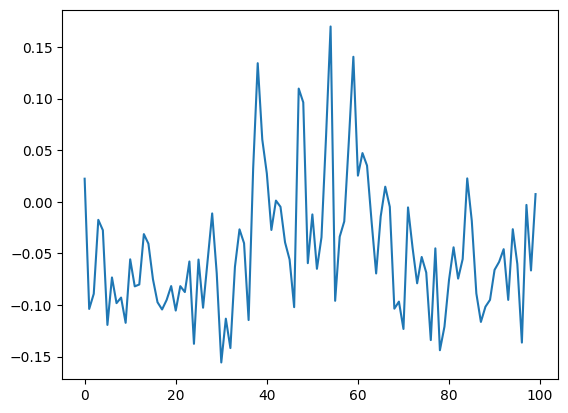

In [8]:
plt.plot(ts_all_filter.mean(axis=(1,2)))

In [9]:
ts_all_filter.mean(axis=(1,2), keepdims=True).shape

(100, 1, 1)

In [10]:
# (Regions, Time, Patients) = (100, 1200, 94)
ts_all_filter = (ts_all_filter - ts_all_filter.mean(axis=(1,2), keepdims=True)) / ts_all_filter.std(axis=(1,2), keepdims=True)

In [11]:
for i in range(ts_all_filter.shape[2]):
    np.save(f"data_processed/ts_young/timeseries_{i}.npy", ts_all_filter[..., i].transpose().astype(np.float32))

In [12]:
print(fc_mean.shape)
print(fc_all.shape)
print(ts_all.shape)

(100, 100)
(100, 100, 94)
(100, 1200, 94)


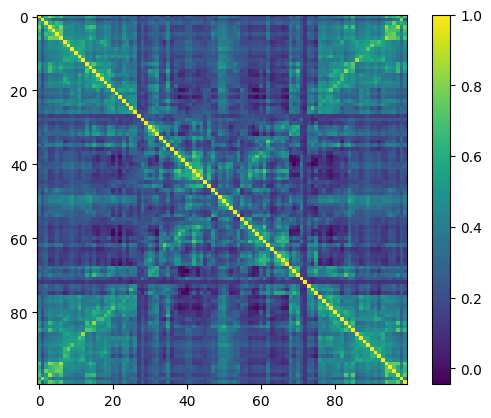

In [13]:
plt.imshow(fc_mean)
plt.colorbar()

In [14]:
patient = ts_all_filter[..., 0]
patient_fft = np.fft.fft(patient, axis=1)
patient_magnitude = np.abs(patient_fft)

In [15]:
k = 10
indices = np.argsort(patient_magnitude, axis=1)[:,-k:]   # indices of the k largest magnitudes

# Create a filtered FFT: zeros everywhere except the top-k freqs
filtered_fft = np.zeros_like(patient_fft, dtype=complex)
rows = np.arange(patient_fft.shape[0])[:, None]
filtered_fft[rows, indices] = patient_fft[rows, indices]

# Inverse FFT to reconstruct
reconstructed = np.fft.ifft(filtered_fft, axis=1).real

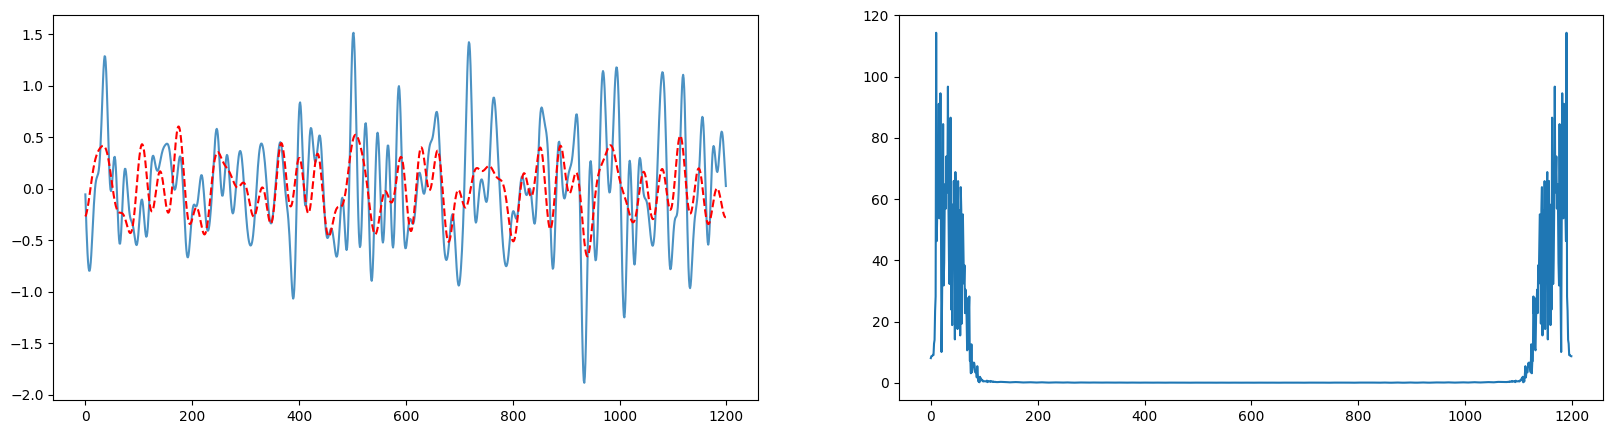

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
ax1.plot(patient[0], label='Original', alpha=0.8)
ax1.plot(reconstructed[0], linestyle='dashed', color='red', label='Reconstructed')
ax2.plot(patient_magnitude[0])
plt.show()

# Bandpass filter example

In [5]:
data = []
for i in range(30):
    x = np.load(f"data_processed/ts_young/timeseries_{i}.npy").astype(np.float32)
    data.append(x)

In [22]:
x0 = data[0]

In [23]:
from scipy.signal import hilbert

In [28]:
hilbert_x0 = hilbert(x0, axis=0)

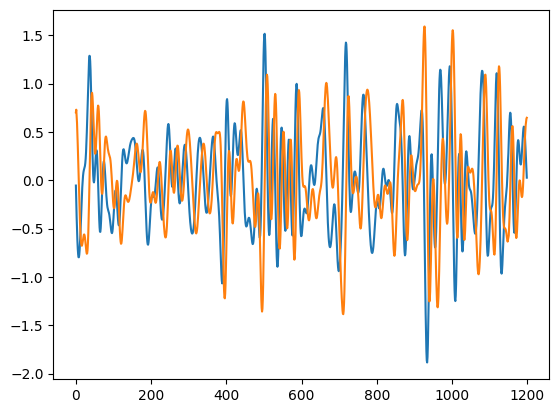

In [29]:
plt.plot(hilbert_x0[...,0].real)
plt.plot(hilbert_x0[...,0].imag)

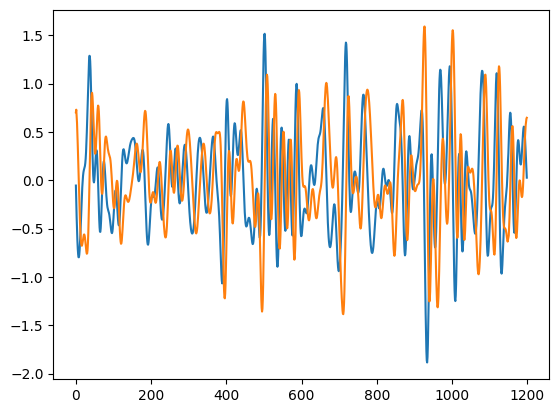

In [27]:
plt.plot(hilbert(x0[...,0]).real)
plt.plot(hilbert(x0[...,0]).imag)

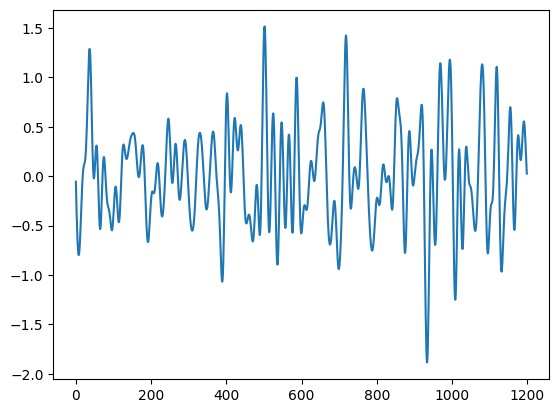

In [15]:
plt.plot(x0)